#**Dataset** **and** **Frameworks**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_status', 'employment', 'installment_rate', 'personal_status',
    'other_parties', 'residence_since', 'property_magnitude', 'age',
    'other_payment_plans', 'housing', 'existing_credits', 'job',
    'num_dependents', 'own_telephone', 'foreign_worker', 'target'
]

df = pd.read_csv(url, sep=' ', header=None, names=columns)
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


#**Error** **Checking**

In [ ]:
print("Shape:", df.shape)
df.info()
print(df.isnull().sum())

Shape: (1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   checking_status      1000 non-null   object
 1   duration             1000 non-null   int64 
 2   credit_history       1000 non-null   object
 3   purpose              1000 non-null   object
 4   credit_amount        1000 non-null   int64 
 5   savings_status       1000 non-null   object
 6   employment           1000 non-null   object
 7   installment_rate     1000 non-null   int64 
 8   personal_status      1000 non-null   object
 9   other_parties        1000 non-null   object
 10  residence_since      1000 non-null   int64 
 11  property_magnitude   1000 non-null   object
 12  age                  1000 non-null   int64 
 13  other_payment_plans  1000 non-null   object
 14  housing              1000 non-null   object
 15  existing_credits     1000 non-null   i

#**Balance** **Checking**

target
1    700
2    300
Name: count, dtype: int64


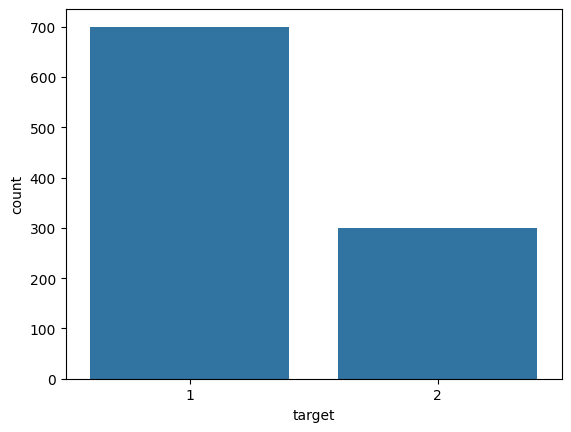

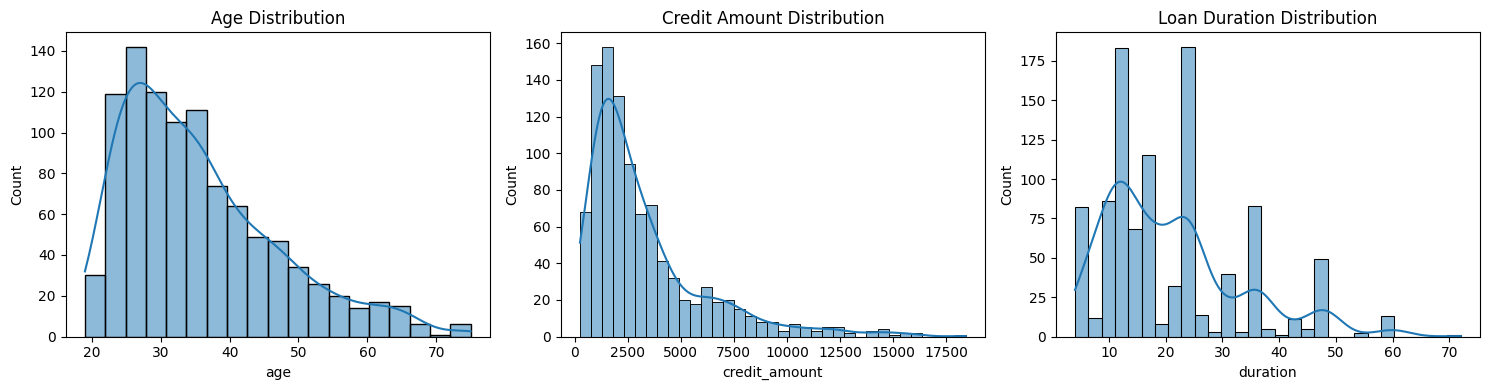

In [ ]:
print(df['target'].value_counts())
sns.countplot(x='target',data=df)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['age'], kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(df['credit_amount'], kde=True, ax=axes[1])
axes[1].set_title('Credit Amount Distribution')

sns.histplot(df['duration'], kde=True, ax=axes[2])
axes[2].set_title('Loan Duration Distribution')

plt.tight_layout()
plt.show()

#**Category** **Remap**

In [ ]:
df['target'] = df['target'].map({1:0, 2:1})
print(df['target'].value_counts())

target
0    700
1    300
Name: count, dtype: int64


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('target')

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Numeric columns: ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents']


In [ ]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df_encoded.shape)
df_encoded.head()

(1000, 49)


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target,checking_status_A12,checking_status_A13,...,property_magnitude_A124,other_payment_plans_A142,other_payment_plans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,own_telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,0,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,1,True,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,0,False,False,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,0,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,1,False,False,...,True,False,True,False,True,False,True,False,False,False


#**Train/Test split**

In [ ]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (800, 48)
Test shape: (200, 48)
Train class balance:
 target
0    0.7
1    0.3
Name: proportion, dtype: float64
Test class balance:
 target
0    0.7
1    0.3
Name: proportion, dtype: float64


#**Feature Scaling and Logistic Regression Implementation**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       140
           1       0.67      0.53      0.59        60

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200

ROC-AUC: 0.8039285714285714
[[124  16]
 [ 28  32]]


#**Random Forest Implementation**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print(confusion_matrix(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.78      0.94      0.85       140
           1       0.72      0.38      0.50        60

    accuracy                           0.77       200
   macro avg       0.75      0.66      0.68       200
weighted avg       0.76      0.77      0.75       200

ROC-AUC: 0.7896428571428571
[[131   9]
 [ 37  23]]


In [ ]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10)

,0
credit_amount,0.108293
duration,0.090501
age,0.082971
checking_status_A14,0.082946
installment_rate,0.039217
residence_since,0.037112
credit_history_A34,0.027052
other_payment_plans_A143,0.026313
savings_status_A65,0.022149
existing_credits,0.020818


In [ ]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_rf)

custom_threshold = 0.4
y_pred_adjusted = (y_pred_proba_rf >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80       140
           1       0.53      0.53      0.53        60

    accuracy                           0.72       200
   macro avg       0.67      0.67      0.67       200
weighted avg       0.72      0.72      0.72       200



#**Final Threshold selection and result**

In [ ]:
final_threshold = 0.4
y_pred_final = (y_pred_proba_rf >= final_threshold).astype(int)

print("Final Model Performance (Random Forest, threshold=0.4)")
print(classification_report(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print(confusion_matrix(y_test, y_pred_final))

Final Model Performance (Random Forest, threshold=0.4)
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       140
           1       0.53      0.53      0.53        60

    accuracy                           0.72       200
   macro avg       0.67      0.67      0.67       200
weighted avg       0.72      0.72      0.72       200

ROC-AUC: 0.7896428571428571
[[112  28]
 [ 28  32]]
